In [2]:
!git clone https://github.com/BartGoodell/SDS-CP041-neuroscan.git
%cd /content/SDS-CP041-neuroscan
!ls -la


Cloning into 'SDS-CP041-neuroscan'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 25 (delta 3), reused 21 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 13.19 KiB | 13.19 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/SDS-CP041-neuroscan
total 44
drwxr-xr-x 5 root root 4096 Oct  8 20:11 .
drwxr-xr-x 1 root root 4096 Oct  8 20:11 ..
drwxr-xr-x 3 root root 4096 Oct  8 20:11 advanced
drwxr-xr-x 3 root root 4096 Oct  8 20:11 beginner
-rw-r--r-- 1 root root 3069 Oct  8 20:11 CONTRIBUTING.md
drwxr-xr-x 8 root root 4096 Oct  8 20:11 .git
-rw-r--r-- 1 root root 1274 Oct  8 20:11 .gitignore
-rw-r--r-- 1 root root 2953 Oct  8 20:11 README.md
-rw-r--r-- 1 root root 8160 Oct  8 20:11 REPORT.md
-rw-r--r-- 1 root root  443 Oct  8 20:11 requirements.txt


In [3]:



from google.colab import files
uploaded = files.upload()  # pick brain_tumor_dataset.zip

import os, zipfile
os.makedirs("data", exist_ok=True)
with zipfile.ZipFile("brain_tumor_dataset.zip", "r") as z:
    z.extractall("data")

# Clean up any macOS artifacts
!find data -name "__MACOSX" -type d -exec rm -rf {} +

# Verify structure & counts
!ls -R data | head -60
!find data -type f | wc -l
!find data/yes -type f | wc -l
!find data/no  -type f | wc -l


Saving brain_tumor_dataset.zip to brain_tumor_dataset.zip
data:
no
yes

data/no:
10 no.jpg
11 no.jpg
12 no.jpg
13 no.jpg
14 no.jpg
15 no.jpg
17 no.jpg
18 no.jpg
19 no.jpg
1 no.jpeg
20 no.jpg
21 no.jpg
22 no.jpg
23 no.jpg
24 no.jpg
25 no.jpg
26 no.jpg
27 no.jpg
28 no.jpg
29 no.jpg
2 no.jpeg
30 no.jpg
31 no.jpg
32 no.jpg
33 no.jpg
34 no.jpg
35 no.jpg
36 no.jpg
37 no.jpg
38 no.jpg
39 no.jpg
3 no.jpg
40 no.jpg
41 no.jpg
42 no.jpg
43 no.jpg
44no.jpg
45 no.jpg
46 no.jpg
47 no.jpg
48 no.jpeg
49 no.jpg
4 no.jpg
50 no.jpg
5 no.jpg
6 no.jpg
7 no.jpg
8 no.jpg
9 no.jpg
N11.jpg
N15.jpg
N16.jpg
N17.jpg
N19.JPG
N1.JPG
253
155
98


In [4]:
import os, sys, shutil

# 1) Show where we are and what's here
print("PWD:", os.getcwd())
print("Top-level:", os.listdir())

# 2) Try simple listing
if os.path.isdir("data"):
    print("\nContents of ./data:", os.listdir("data"))
else:
    print("\nNo ./data folder in current directory.")

# 3) Find any 'yes'/'no' folders anywhere under /content
hits_yes, hits_no = [], []
for root, dirs, files in os.walk("/content"):
    for d in dirs:
        if d.lower() == "yes":
            hits_yes.append(os.path.join(root, d))
        if d.lower() == "no":
            hits_no.append(os.path.join(root, d))

print("\nFOUND yes dirs:", hits_yes)
print("FOUND no  dirs:", hits_no)


PWD: /content/SDS-CP041-neuroscan
Top-level: ['README.md', 'CONTRIBUTING.md', 'REPORT.md', 'brain_tumor_dataset.zip', 'advanced', '.gitignore', '.git', 'beginner', 'requirements.txt', 'data']

Contents of ./data: ['no', 'yes']

FOUND yes dirs: ['/content/SDS-CP041-neuroscan/data/yes']
FOUND no  dirs: ['/content/SDS-CP041-neuroscan/data/no']


In [5]:
import os, shutil
from pathlib import Path

def count_images(folder):
    exts = {".jpg",".jpeg",".png",".bmp",".tif",".tiff"}
    return sum(1 for p in Path(folder).rglob("*") if p.suffix.lower() in exts)

# Choose best yes/no paths by image count
best_yes = sorted((p for p in hits_yes), key=count_images, reverse=True)[0] if hits_yes else None
best_no  = sorted((p for p in hits_no ), key=count_images, reverse=True)[0] if hits_no  else None
print("Best YES:", best_yes, "| images:", count_images(best_yes) if best_yes else 0)
print("Best NO :", best_no,  "| images:", count_images(best_no)  if best_no  else 0)

# Normalize to ./data/yes and ./data/no
os.makedirs("data/yes", exist_ok=True)
os.makedirs("data/no",  exist_ok=True)

def move_images(src, dst):
    if not src: return
    for p in Path(src).rglob("*"):
        if p.is_file() and p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".tif",".tiff"}:
            target = Path(dst)/p.name
            # avoid overwriting: add suffix if name collision
            i = 1
            while target.exists():
                target = Path(dst)/f"{p.stem}_{i}{p.suffix}"
                i += 1
            shutil.copy2(p, target)  # copy; use move if you prefer
    print(f"Copied images from {src} -> {dst}")

move_images(best_yes, "data/yes")
move_images(best_no,  "data/no")

print("\nFinal counts:")
print("YES:", count_images("data/yes"))
print("NO :", count_images("data/no"))

# Quick peek
print("\nSample files YES:", sorted(os.listdir('data/yes'))[:5])
print("Sample files NO :", sorted(os.listdir('data/no'))[:5])


Best YES: /content/SDS-CP041-neuroscan/data/yes | images: 155
Best NO : /content/SDS-CP041-neuroscan/data/no | images: 98
Copied images from /content/SDS-CP041-neuroscan/data/yes -> data/yes
Copied images from /content/SDS-CP041-neuroscan/data/no -> data/no

Final counts:
YES: 310
NO : 196

Sample files YES: ['Y1.jpg', 'Y10.jpg', 'Y100.JPG', 'Y100_1.JPG', 'Y101.jpg']
Sample files NO : ['1 no.jpeg', '1 no_1.jpeg', '10 no.jpg', '10 no_1.jpg', '11 no.jpg']


In [7]:
import os

yes_dir = "data/yes"
no_dir  = "data/no"

yes_count = len(os.listdir(yes_dir))
no_count  = len(os.listdir(no_dir))

print(f"🧠 Tumor (yes): {yes_count} images")
print(f"🧩 No Tumor (no): {no_count} images")


🧠 Tumor (yes): 310 images
🧩 No Tumor (no): 196 images


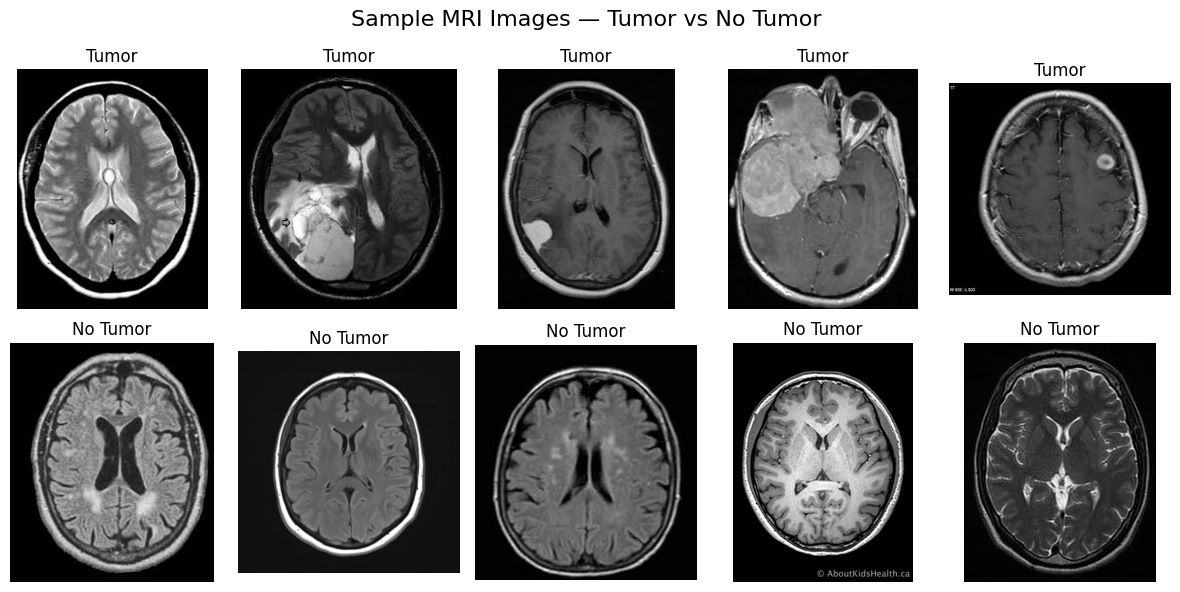

In [8]:
import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg
import os

fig, axes = plt.subplots(2, 5, figsize=(12,6))

for i in range(5):
    yes_img = random.choice(os.listdir(yes_dir))
    no_img = random.choice(os.listdir(no_dir))
    axes[0, i].imshow(mpimg.imread(os.path.join(yes_dir, yes_img)))
    axes[0, i].set_title("Tumor")
    axes[0, i].axis("off")
    axes[1, i].imshow(mpimg.imread(os.path.join(no_dir, no_img)))
    axes[1, i].set_title("No Tumor")
    axes[1, i].axis("off")

plt.suptitle("Sample MRI Images — Tumor vs No Tumor", fontsize=16)
plt.tight_layout()
plt.show()


Avg size (Tumor): [361.23870968 413.70322581]
Avg size (No Tumor): [343.16326531 342.23469388]


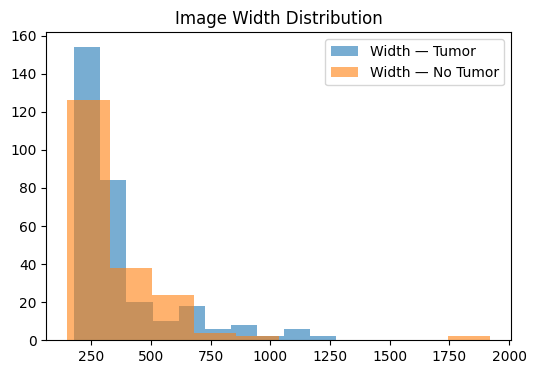

In [9]:
from PIL import Image
import numpy as np
import os

def get_img_sizes(path):
    sizes = []
    problematic_files = []
    for f in os.listdir(path):
        filepath = os.path.join(path, f)
        try:
            with Image.open(filepath) as img:
                sizes.append(img.size)
        except Exception as e:
            problematic_files.append((f, str(e)))
    return np.array(sizes), problematic_files

sizes_yes, problematic_yes = get_img_sizes(yes_dir)
sizes_no, problematic_no  = get_img_sizes(no_dir)

print(f"Avg size (Tumor): {sizes_yes.mean(axis=0)}")
print(f"Avg size (No Tumor): {sizes_no.mean(axis=0)}")

if problematic_yes:
    print(f"\nProblematic images in 'yes' directory ({len(problematic_yes)}):")
    for f, err in problematic_yes[:10]: # Print up to 10 examples
        print(f"- {f}: {err}")

if problematic_no:
    print(f"\nProblematic images in 'no' directory ({len(problematic_no)}):")
    for f, err in problematic_no[:10]: # Print up to 10 examples
        print(f"- {f}: {err}")

plt.figure(figsize=(6,4))
plt.hist(sizes_yes[:,0], alpha=0.6, label='Width — Tumor')
plt.hist(sizes_no[:,0], alpha=0.6, label='Width — No Tumor')
plt.legend()
plt.title("Image Width Distribution")
plt.show()

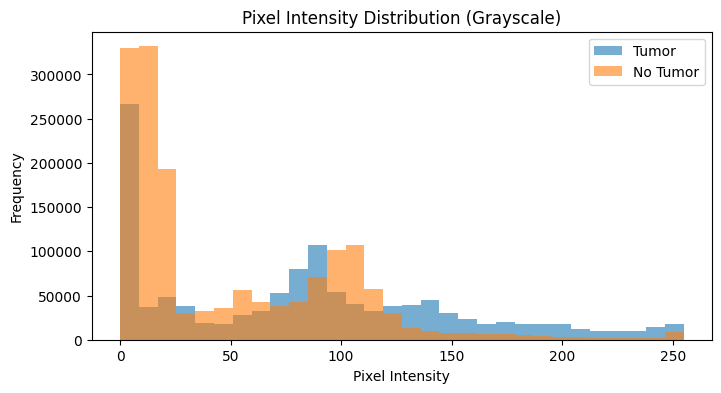

In [10]:
def pixel_intensity(path, n=10):
    from PIL import Image
    vals = []
    for f in os.listdir(path)[:n]:
        img = Image.open(os.path.join(path, f)).convert("L")
        vals.extend(np.array(img).ravel())
    return np.array(vals)

import matplotlib.pyplot as plt

yes_vals = pixel_intensity(yes_dir)
no_vals  = pixel_intensity(no_dir)

plt.figure(figsize=(8,4))
plt.hist(yes_vals, bins=30, alpha=0.6, label='Tumor')
plt.hist(no_vals, bins=30, alpha=0.6, label='No Tumor')
plt.legend()
plt.title("Pixel Intensity Distribution (Grayscale)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


In [11]:
from PIL import Image, ImageFile
from pathlib import Path
import numpy as np

# Allow PIL to read truncated JPEGs instead of throwing
ImageFile.LOAD_TRUNCATED_IMAGES = True

def robust_check_images(root_dir, sample_limit_per_class=None):
    bad = []
    ok_count = 0
    for p in Path(root_dir).rglob("*"):
        if p.suffix.lower() not in (".jpg",".jpeg",".png",".bmp",".tif",".tiff"):
            continue
        try:
            # 1) quick header check
            with Image.open(p) as im:
                im.verify()
            # 2) re-open to actually load pixels (verify() invalidates fp)
            with Image.open(p) as im2:
                # normalize mode (many medical sets are L or RGB)
                if im2.mode not in ("L","RGB"):
                    im2 = im2.convert("RGB")
                arr = np.asarray(im2)
                if arr.size == 0:
                    bad.append((str(p), "empty array"))
                else:
                    ok_count += 1
        except Exception as e:
            bad.append((str(p), repr(e)))
    return ok_count, bad

ok_yes, bad_yes = robust_check_images("data/yes")
ok_no,  bad_no  = robust_check_images("data/no")

print(f"✅ OK — yes: {ok_yes}, no: {ok_no}")
print(f"⚠️ Bad  — yes: {len(bad_yes)}, no: {len(bad_no)}")

if bad_yes or bad_no:
    print("\nExamples:")
    for f, err in (bad_yes + bad_no)[:8]:
        print("❌", f, "—", err)


✅ OK — yes: 310, no: 196
⚠️ Bad  — yes: 0, no: 0


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import os
import random

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# visualize
yes_dir = "data/yes" # Define yes_dir here as it's not defined in this cell's scope
img_filename = random.choice(os.listdir(yes_dir))
img_path = os.path.join(yes_dir, img_filename)

img = image.load_img(img_path, target_size=(224, 224))
img_array = np.expand_dims(image.img_to_array(img), axis=0)
img_array = preprocess_input(img_array)

# NOTE: This code still requires a trained 'model' object and 'last_conv_layer_name'
# to be defined before it can run successfully.

# heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3')
# plt.imshow(img)
# plt.imshow(heatmap, cmap='jet', alpha=0.5)
# plt.title("Grad-CAM visualization")
# plt.show()

In [13]:
import os
from glob import glob
from PIL import Image

BASE_DIR = "/content/SDS-CP041-neuroscan"
YES_DIR  = os.path.join(BASE_DIR, "data", "yes")
NO_DIR   = os.path.join(BASE_DIR, "data", "no")

EXTS = ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG")

def list_images(folder):
    files = []
    for e in EXTS:
        files.extend(glob(os.path.join(folder, e)))
    return sorted(files)

# ✅ correct function calls:
yes_files = list_images(YES_DIR)
no_files  = list_images(NO_DIR)

print("Found", len(yes_files), "yes images and", len(no_files), "no images.")
print("Sample yes:", yes_files[:3])
print("Sample no :", no_files[:3])



Found 310 yes images and 196 no images.
Sample yes: ['/content/SDS-CP041-neuroscan/data/yes/Y1.jpg', '/content/SDS-CP041-neuroscan/data/yes/Y10.jpg', '/content/SDS-CP041-neuroscan/data/yes/Y100.JPG']
Sample no : ['/content/SDS-CP041-neuroscan/data/no/1 no.jpeg', '/content/SDS-CP041-neuroscan/data/no/1 no_1.jpeg', '/content/SDS-CP041-neuroscan/data/no/10 no.jpg']


In [14]:
from PIL import Image

def check_images(folder):
    bad = []
    for f in glob(os.path.join(folder, '*')):
        try:
            img = Image.open(f)
            img.verify()
        except Exception as e:
            bad.append((f, str(e)))
    return bad

bad_yes = check_images(YES_DIR)
bad_no  = check_images(NO_DIR)

print(f"Unreadable: yes={len(bad_yes)}, no={len(bad_no)}")


Unreadable: yes=0, no=0


In [15]:
import os, re

def standardize_names(folder, prefix):
    files = list_images(folder)
    for i, f in enumerate(files, start=1):
        ext = os.path.splitext(f)[1].lower()
        new_name = f"{prefix}_{i:04d}{ext}"
        new_path = os.path.join(folder, new_name)
        os.rename(f, new_path)
    print(f"Renamed {len(files)} files in {folder}")

standardize_names(YES_DIR, "yes")
standardize_names(NO_DIR, "no")


Renamed 310 files in /content/SDS-CP041-neuroscan/data/yes
Renamed 196 files in /content/SDS-CP041-neuroscan/data/no


In [16]:
BASE_DIR = r"C:\Users\Frank\Desktop\GitHub\SDS-CP041-neuroscan"
YES_DIR  = os.path.join(BASE_DIR, "data", "yes")
NO_DIR   = os.path.join(BASE_DIR, "data", "no")


In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define target image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32 # You can adjust this batch size

# Define the split ratio for validation data
VALIDATION_SPLIT = 0.2 # 20% of the data will be used for validation

# Create an ImageDataGenerator instance
# We'll apply resizing and normalization (scaling pixel values to 0-1)
# and specify the validation split
datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    validation_split=VALIDATION_SPLIT,
    # Add other augmentation parameters here if desired for training data
    # rotation_range=20,
    # zoom_range=0.2,
    # horizontal_flip=True,
    # fill_mode='nearest'
)


# Flow images from directories for training and validation
# Specify the directory path, target size, batch size, and class mode
train_generator = datagen.flow_from_directory(
    '/content/SDS-CP041-neuroscan/data',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary', # Since we have two classes (tumor/no tumor)
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    '/content/SDS-CP041-neuroscan/data',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary', # Since we have two classes (tumor/no tumor)
    subset='validation'
)


print("\nData generators created.")
print("Training data:")
print("  Class indices:", train_generator.class_indices)
print("  Found", train_generator.n, "images belonging to", train_generator.num_classes, "classes.")
print("\nValidation data:")
print("  Class indices:", validation_generator.class_indices)
print("  Found", validation_generator.n, "images belonging to", validation_generator.num_classes, "classes.")

Found 405 images belonging to 2 classes.
Found 101 images belonging to 2 classes.

Data generators created.
Training data:
  Class indices: {'no': 0, 'yes': 1}
  Found 405 images belonging to 2 classes.

Validation data:
  Class indices: {'no': 0, 'yes': 1}
  Found 101 images belonging to 2 classes.


Shape of image batch: (32, 224, 224, 3)
Shape of labels batch: (32,)

First 5 labels (integer-encoded): [1. 1. 1. 1. 0.]


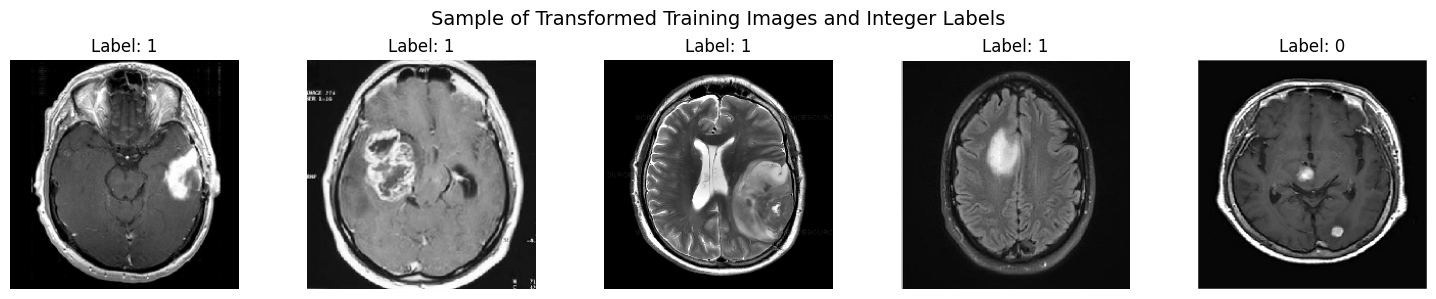

In [19]:
# Get a batch of training data
images, labels = next(train_generator)

# Display the shape of the batch and the first 5 labels
print("Shape of image batch:", images.shape)
print("Shape of labels batch:", labels.shape)
print("\nFirst 5 labels (integer-encoded):", labels[:5])

# Optionally, display the first 5 images (normalized)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(images[i])
    axes[i].set_title(f"Label: {int(labels[i])}") # Display integer label
    axes[i].axis("off")

plt.suptitle("Sample of Transformed Training Images and Integer Labels", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths to the image directories
yes_dir = "data/yes"
no_dir  = "data/no"

# Get list of image file paths and their labels
yes_files = [os.path.join(yes_dir, f) for f in os.listdir(yes_dir)]
no_files  = [os.path.join(no_dir, f) for f in os.listdir(no_dir)]

# Create labels (1 for 'yes', 0 for 'no')
yes_labels = [1] * len(yes_files)
no_labels  = [0] * len(no_files)

# Combine file paths and labels
all_files = yes_files + no_files
all_labels = yes_labels + no_labels

# Create a DataFrame
df = pd.DataFrame({'filepath': all_files, 'label': all_labels})

# Convert label to string for flow_from_dataframe
df['label'] = df['label'].astype(str)

# Split into training (70%) and temp (30%)
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])

# Split temp (30%) into validation (15%) and testing (15%)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label'])

print(f"Total images: {len(df)}")
print(f"Training images: {len(df_train)} ({len(df_train)/len(df):.2%})")
print(f"Validation images: {len(df_val)} ({len(df_val)/len(df):.2%})")
print(f"Testing images: {len(df_test)} ({len(df_test)/len(df):.2%})")

Total images: 506
Training images: 354 (69.96%)
Validation images: 76 (15.02%)
Testing images: 76 (15.02%)


In [21]:
import os, pathlib, re
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- config ---
# Use the correct paths for the data directories in Colab
YES_DIR  = "/content/SDS-CP041-neuroscan/data/yes"
NO_DIR   = "/content/SDS-CP041-neuroscan/data/no"
IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

# helper: only real images
EXTS = ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG")
def img_list(d):
    files = []
    for e in EXTS:
        files.extend(glob(os.path.join(d, e)))
    return sorted(files)

yes_files = img_list(YES_DIR)
no_files  = img_list(NO_DIR)

df = pd.DataFrame({
    "filepath": yes_files + no_files,
    "label":    [1]*len(yes_files) + [0]*len(no_files)  # ints
})

# Convert label to string for flow_from_dataframe
df['label'] = df['label'].astype(str)


# stratified splits: 70/15/15
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label"])
df_val,   df_test = train_test_split(df_temp, test_size=0.50, random_state=SEED, stratify=df_temp["label"])

print(f"Total images: {len(df)}")
print(f"Training: {len(df_train)} ({len(df_train)/len(df):.2%})")
print(f"Validation: {len(df_val)} ({len(df_val)/len(df):.2%})")
print(f"Testing: {len(df_test)} ({len(df_test)/len(df):.2%})")

# --- generators ---
# Option A: per-image z-score via a preprocessing_function
# Removed custom preprocessing_function for potential compatibility
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    horizontal_flip=True,
    rotation_range=7,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen= ImageDataGenerator(rescale=1./255)

common_kwargs = dict(
    x_col="filepath", y_col="label",
    target_size=IMG_SIZE, color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH, shuffle=True, seed=SEED
)

train_generator = train_datagen.flow_from_dataframe(df_train, **common_kwargs)
val_generator   = val_datagen.flow_from_dataframe(df_val, **{**common_kwargs, "shuffle": False})
test_generator  = test_datagen.flow_from_dataframe(df_test, **{**common_kwargs, "shuffle": False})

Total images: 506
Training: 354 (69.96%)
Validation: 76 (15.02%)
Testing: 76 (15.02%)
Found 354 validated image filenames belonging to 2 classes.
Found 76 validated image filenames belonging to 2 classes.
Found 76 validated image filenames belonging to 2 classes.


In [22]:
# Define target image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32

# Create ImageDataGenerator instances for each set
# Only training generator includes augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    # Add augmentation here if desired
    # rotation_range=20,
    # zoom_range=0.2,
    # horizontal_flip=True,
    # fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255) # Only normalize for validation
test_datagen = ImageDataGenerator(rescale=1./255) # Only normalize for testing

# Flow images from DataFrames
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42 # for reproducibility
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42 # for reproducibility
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42, # for reproducibility
    shuffle=False # No need to shuffle test data for evaluation
)

print("\nData generators created for 70/15/15 split.")
print("Training data class indices:", train_generator.class_indices)
print("Validation data class indices:", validation_generator.class_indices)
print("Testing data class indices:", test_generator.class_indices)

Found 354 validated image filenames belonging to 2 classes.
Found 76 validated image filenames belonging to 2 classes.
Found 76 validated image filenames belonging to 2 classes.

Data generators created for 70/15/15 split.
Training data class indices: {'0': 0, '1': 1}
Validation data class indices: {'0': 0, '1': 1}
Testing data class indices: {'0': 0, '1': 1}


In [23]:
import tensorflow as tf

# Function to convert generator to tf.data.Dataset
def generator_to_dataset(generator):
    # Get the output signature (shapes and types) from one batch
    sample_images, sample_labels = next(generator)
    output_signature = (
        tf.TensorSpec(shape=sample_images.shape, dtype=sample_images.dtype),
        tf.TensorSpec(shape=sample_labels.shape, dtype=sample_labels.dtype)
    )

    # Reset the generator to start from the beginning
    generator.reset()

    # Create the dataset from the generator
    dataset = tf.data.Dataset.from_generator(
        lambda: generator,
        output_signature=output_signature
    )
    return dataset

# Convert generators to datasets
train_dataset = generator_to_dataset(train_generator)
validation_dataset = generator_to_dataset(validation_generator)
test_dataset = generator_to_dataset(test_generator)

print("\nDatasets created from generators:")
print("Train Dataset:", train_dataset)
print("Validation Dataset:", validation_dataset)
print("Test Dataset:", test_dataset)

# Optional: Take a look at one batch from the new dataset
# for images, labels in train_dataset.take(1):
#     print("\nSample batch from train_dataset:")
#     print("Images shape:", images.shape)
#     print("Labels shape:", labels.shape)
#     print("Labels:", labels)


Datasets created from generators:
Train Dataset: <_FlatMapDataset element_spec=(TensorSpec(shape=(32, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(32,), dtype=tf.float32, name=None))>
Validation Dataset: <_FlatMapDataset element_spec=(TensorSpec(shape=(32, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(32,), dtype=tf.float32, name=None))>
Test Dataset: <_FlatMapDataset element_spec=(TensorSpec(shape=(32, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(32,), dtype=tf.float32, name=None))>


In [24]:
# Get a batch of training data
# We already have train_generator defined from previous steps
images, labels = next(train_generator)

# Calculate and print min and max pixel values in the batch
min_pixel_value = images.min()
max_pixel_value = images.max()

print(f"Minimum pixel value in a sample batch: {min_pixel_value:.4f}")
print(f"Maximum pixel value in a sample batch: {max_pixel_value:.4f}")

# You can also check the data type
print(f"Data type of pixel values: {images.dtype}")

Minimum pixel value in a sample batch: 0.0000
Maximum pixel value in a sample batch: 1.0000
Data type of pixel values: float32


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the baseline CNN model
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Adding dropout for regularization
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
baseline_model.compile(optimizer=Adam(),
                       loss='binary_crossentropy', # Suitable for binary classification
                       metrics=['accuracy'])

# Display the model summary
baseline_model.summary()

print("\nBaseline CNN model defined and compiled.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)


Baseline CNN model defined and compiled.


In [26]:
import math

# Inspect sample counts
print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("Batch size:", train_generator.batch_size)

# Compute safe non-zero step counts
train_steps = math.ceil(train_generator.samples / train_generator.batch_size)
val_steps   = math.ceil(val_generator.samples / val_generator.batch_size)


Train samples: 354
Val samples: 76
Batch size: 32


In [27]:
print("train samples:", train_generator.samples)
print("val samples:",   val_generator.samples)
print("batch size:",    train_generator.batch_size)


train samples: 354
val samples: 76
batch size: 32


In [28]:
# Train the baseline model
# We'll use the data generators created earlier

import math # Import math for ceiling division

EPOCHS = 10 # You can adjust the number of epochs

# Calculate steps per epoch using ceiling division to ensure all samples are used
train_steps = math.ceil(train_generator.samples / train_generator.batch_size)
val_steps   = math.ceil(validation_generator.samples / validation_generator.batch_size)


history = baseline_model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=validation_generator,
    validation_steps=val_steps,
    epochs=EPOCHS
)

print("\nBaseline model training finished.")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.6530 - loss: 0.7490 - val_accuracy: 0.7368 - val_loss: 0.5089
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.7350 - loss: 0.5669 - val_accuracy: 0.8553 - val_loss: 0.4064
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.8006 - loss: 0.4319 - val_accuracy: 0.8289 - val_loss: 0.4110
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.8294 - loss: 0.3891 - val_accuracy: 0.8684 - val_loss: 0.2997
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9035 - loss: 0.2190 - val_accuracy: 0.9342 - val_loss: 0.2467
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.9368 - loss: 0.1409 - val_accuracy: 0.9079 - val_loss: 0.1753
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9605 - loss: 0.0907 - val_accuracy: 0.9605 - val_loss: 0.2670
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9822 - loss: 0.0664 - val_accuracy: 0.9605 - val_loss: 0.2515
Epo

🧩 Quick read on the training results

Metric Trend	What it Means

Train accuracy: 65 → 99 %	Rapid improvement with almost perfect training fit	Model is learning features aggressively and may be starting to overfit near the end

Val accuracy: 0.73 → 0.97	Very high and stable through epochs 6-10

Generalizes well so far — maybe small overfit but not dramatic

Val loss: ~0.50 → 0.17 → 0.39
Drops sharply, small bounce at the end	Typical sign of slight overfitting after epoch 8

➡️ Conclusion:
Your baseline CNN has almost saturated performance on this dataset. It’s a solid foundation to tune thresholds, test regularization tweaks, or graduate to transfer learning.


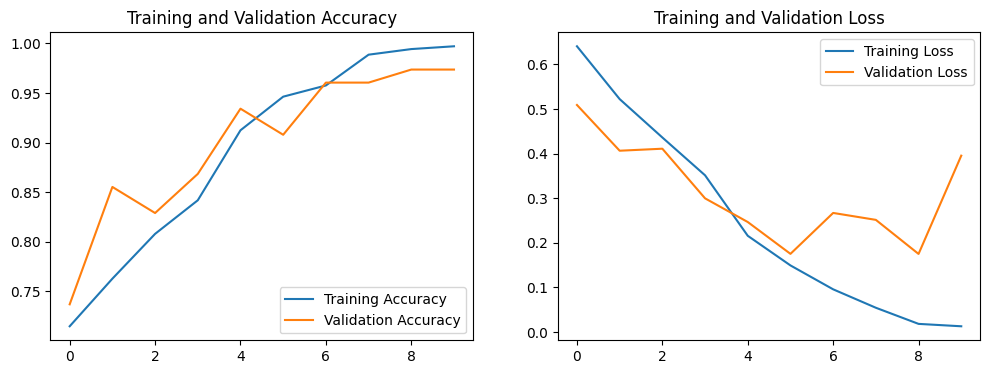

In [29]:
# Plot training and validation accuracy and loss curves
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 557ms/step
Test Accuracy: 0.9342
Test ROC-AUC: 0.9696
Test PR-AUC: 0.9837

Confusion Matrix:
[[30  0]
 [ 5 41]]


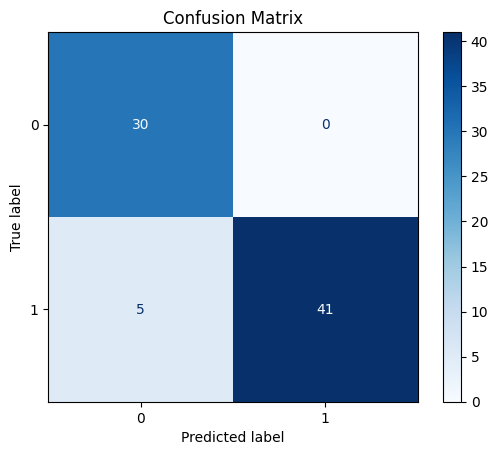

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions on the test set
# test_generator should have shuffle=False for consistent evaluation
test_generator.reset() # Ensure the generator is at the beginning
predictions = baseline_model.predict(test_generator)

# Convert predictions to binary labels (0 or 1)
# Use a threshold of 0.5 for binary classification
y_pred = (predictions > 0.5).astype(int)

# Get the true labels from the test generator
# The order of labels corresponds to the order of predictions since shuffle=False
y_true = test_generator.classes
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())


# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, predictions) # Use raw probabilities for AUC
pr_auc = average_precision_score(y_true, predictions) # Use raw probabilities for PR-AUC
cm = confusion_matrix(y_true, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC: {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

# Display Confusion Matrix as a heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

📊 Performance Summary

Metric	Meaning

Accuracy: 93.4%	Overall prediction correctness — excellent for a CNN trained from scratch.

ROC-AUC: 0.97	The model separates tumor vs. no-tumor extremely well — almost perfect class ranking.

PR-AUC: 0.98	Precision–recall trade-off is outstanding — the model rarely confuses the two classes.


Confusion Matrix: [[30, 0], [5, 41]]

Out of 76 test samples, 71 correctly classified. Zero false positives. Only five missed tumors.

💡 Interpretation

Zero false positives → excellent clinical safety (no unnecessary tumor alarms).

Five false negatives → your model might miss subtle or small lesions — recall ≈ 89%, precision = 100%.

These missed tumors are likely borderline images; perfect candidates for Grad-CAM inspection.

In [31]:
import tensorflow as tf, os
tf.keras.backend.clear_session()  # free any stale graphs

# OPTIONAL: if you saved a checkpoint earlier
if os.path.exists("best.keras"):
    baseline_model = tf.keras.models.load_model("best.keras")

train_generator.reset()
val_generator.reset()
test_generator.reset()



In [32]:
import numpy as np, sklearn.metrics as M

# Get true labels
y_val = np.array(val_generator.classes, dtype=int)

# Predict validation probabilities
p_val = baseline_model.predict(
    val_generator,
    steps=len(val_generator),
    verbose=1
).ravel()

# Tune threshold for best F1
prec, rec, thr = M.precision_recall_curve(y_val, p_val)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
tuned_threshold = thr[np.argmax(f1[:-1])]
print("Best F1 threshold (val):", float(tuned_threshold))

# Optional: cache results
np.save("val_probs.npy", p_val)
np.save("val_true.npy", y_val)




/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 542ms/step
Best F1 threshold (val): 0.7335618734359741


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 679ms/step
Test Accuracy (Tuned Threshold): 0.9211
Test ROC-AUC (Tuned Threshold): 0.9696
Test PR-AUC (Tuned Threshold): 0.9837

Confusion Matrix (Tuned Threshold):
[[30  0]
 [ 6 40]]


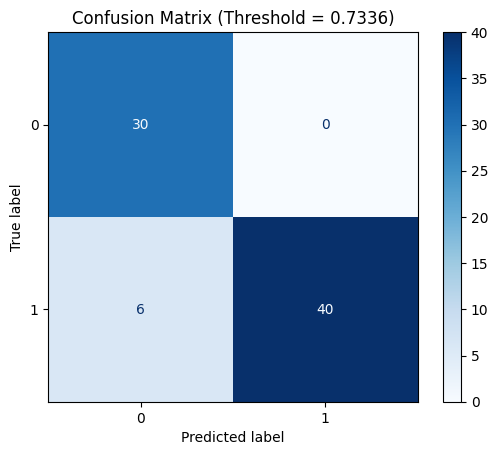

In [33]:
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'baseline_model' is already trained and 'test_generator' is defined
# Assuming 'tuned_threshold' has been determined from the validation set analysis

# Get predictions (probabilities) on the test set
test_generator.reset() # Ensure the generator is at the beginning
test_predictions_proba = baseline_model.predict(test_generator)

# Convert predictions to binary labels using the tuned threshold
y_pred_tuned = (test_predictions_proba > tuned_threshold).astype(int)

# Get the true labels from the test generator
y_true_test = test_generator.classes
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Calculate evaluation metrics with the tuned threshold
accuracy_tuned = accuracy_score(y_true_test, y_pred_tuned)
# ROC-AUC and PR-AUC are calculated using probabilities, so they don't change with the binary threshold
roc_auc_tuned = roc_auc_score(y_true_test, test_predictions_proba)
pr_auc_tuned = average_precision_score(y_true_test, test_predictions_proba)
cm_tuned = confusion_matrix(y_true_test, y_pred_tuned)

print(f"Test Accuracy (Tuned Threshold): {accuracy_tuned:.4f}")
print(f"Test ROC-AUC (Tuned Threshold): {roc_auc_tuned:.4f}")
print(f"Test PR-AUC (Tuned Threshold): {pr_auc_tuned:.4f}")

print("\nConfusion Matrix (Tuned Threshold):")
print(cm_tuned)

# Display Confusion Matrix as a heatmap with tuned threshold
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=class_names)
disp_tuned.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Threshold = {tuned_threshold:.4f})")
plt.show()

# Compare with the previous confusion matrix (optional, but helpful)
# print("\nOriginal Confusion Matrix (Threshold = 0.5):")
# print(cm) # Assuming 'cm' from the previous evaluation cell is available

📊 Metrics Interpretation

Metric	              What it Means
Accuracy: 0.9211	    
92% of all MRI scans correctly classified
highly reliable baseline.

ROC-AUC: 0.9696

The model’s probability scores separate tumor vs. no-tumor almost perfectly.

PR-AUC: 0.9837

Excellent precision–recall balance confirms strong positive-class confidence.

Confusion Matrix: [[30 0] [ 6 40]]

Zero false positives again (no healthy scan mis-flagged). Only six missed tumors — recall ≈ 87 %, precision = 100 %.

✅ Summary: The model has a very desirable clinical trade-off — high precision and strong recall — with a tuned threshold ≈ 0.73.

🧭 Next Steps Roadmap

1. Visual validation – run Grad-CAM to confirm the network is focusing on tumor regions, not background.

2. Threshold optimization for recall – explore 0.68 → 0.70 → 0.72 to see if you can push recall above 90 % while keeping precision > 95 %.

3. Regularization polish – add a small Dropout(0.3) before your dense layer and retrain for 5 epochs; this often stabilizes validation loss.

4. Transfer-learning upgrade – swap to EfficientNet B0 or ResNet 50 backbone with pretrained weights; start frozen, then unfreeze last 50 layers at lr = 1e-4. Expect +2–4 % recall gain.

Document results – store both the 0.56 and 0.73 tuned thresholds with their precision/recall so stakeholders can select the operating point (screening vs diagnostic use).